## Lab 2

### Part 3. Poetry generation

Let's try to generate some poetry using RNNs. 

You have several choices here: 

* The Shakespeare sonnets, file `sonnets.txt` available in the notebook directory.

* Роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина. В предобработанном виде доступен по [ссылке](https://github.com/attatrol/data_sources/blob/master/onegin.txt).

* Some other text source, if it will be approved by the course staff.

Text generation can be designed in several steps:
    
1. Data loading.
2. Dictionary generation.
3. Data preprocessing.
4. Model (neural network) training.
5. Text generation (model evaluation).


In [1]:
import string
import os

import numpy as np

### Data loading: Shakespeare

Shakespeare sonnets are awailable at this [link](http://www.gutenberg.org/ebooks/1041?msg=welcome_stranger). In addition, they are stored in the same directory as this notebook (`sonnetes.txt`). Simple preprocessing is already done for you in the next cell: all technical info is dropped.

In [2]:
if not os.path.exists('sonnets.txt'):
    !wget https://raw.githubusercontent.com/girafe-ai/ml-course/22f_basic/homeworks_basic/lab02_deep_learning/sonnets.txt

with open('sonnets.txt', 'r') as iofile:
    text = iofile.readlines()
    
TEXT_START = 45
TEXT_END = -368
text = text[TEXT_START : TEXT_END]
assert len(text) == 2616

In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [3]:
# Join all the strings into one and lowercase it
# Put result into variable text.

text = ''.join(text).lower()

assert len(text) == 100225, 'Are you sure you have concatenated all the strings?'
assert not any([x in set(text) for x in string.ascii_uppercase]), 'Uppercase letters are present'
print('OK!')

OK!


### Data loading: "Евгений Онегин"


In [ ]:
# !wget https://raw.githubusercontent.com/attatrol/data_sources/master/onegin.txt
    
# with open('onegin.txt', 'r') as iofile:
#     text = iofile.readlines()
    
# text = [x.replace('\t\t', '') for x in text]

In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [ ]:
# Join all the strings into one and lowercase it
# Put result into variable text.

# Your great code here


Put all the characters, that you've seen in the text, into variable `tokens`.

In [4]:
tokens = sorted(set(text))

In [5]:
len(tokens)

38

Create dictionary `token_to_idx = {<char>: <index>}` and dictionary `idx_to_token = {<index>: <char>}`

In [6]:
token_to_idx = {ch: i for i, ch in enumerate(tokens)}
idx_to_token = {v:k for k, v in token_to_idx.items()}

In [7]:
encoded_text = np.array([token_to_idx[char] for char in text])

*Comment: in this task we have only 38 different tokens, so let's use one-hot encoding.*

### Building the model

Now we want to build and train recurrent neural net which would be able to something similar to Shakespeare's poetry.

Let's use vanilla RNN, similar to the one created during the lesson.

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt

In [9]:
class MyRNN(nn.Module):
    
    def __init__(self, vocab_size, embedding_dim, hidden_dim, n_layers=1):
        super(MyRNN, self).__init__()
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, n_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x, hidden):
        x = self.embedding(x)
        x, hidden = self.rnn(x, hidden)
        x = self.dropout(x)
        out = self.fc(x)
        return out, hidden

    def initial_state(self, batch_size):
        return (torch.zeros(self.n_layers, batch_size, self.hidden_dim))

In [10]:
def generate_text_batches(text, batch_size, seq_length):
    total_length = len(text) // (batch_size * seq_length)
    text = text[:total_length * batch_size * seq_length]
    text = text.reshape((batch_size, -1))
    n = text.shape[1]
    for i in range(0, n, seq_length):
        x = text[:, i:i+seq_length]
        y = np.zeros_like(x)
        y[:, :-1] = x[:, 1:]
        y[:, -1] = x[:, 0]
        yield torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

In [11]:
def train_model(model, optimizer, criterion, encoded_text, batch_size, seq_length, epochs):    
    loss_ = []
    progress = tqdm(range(epochs))
    for epoch in progress:
        state = model.initial_state(batch_size)
        for x, y in generate_text_batches(encoded_text, batch_size, seq_length):
            optimizer.zero_grad()
            
            y_pred, state = model(x, state)
            
            loss = criterion(y_pred.transpose(1, 2), y)
            if isinstance(state, tuple):
                state = (state[0].detach(), state[1].detach())
            else:
                state = state.detach()
                
            loss.backward()
            optimizer.step()
            loss_.append(loss.item())
    
    fig, ax = plt.subplots()
    ax.plot(loss_)
    ax.set_xlabel('Steps')
    ax.set_ylabel('Loss')
    ax.grid(True)
    
    return model

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:23<00:00,  1.26it/s]


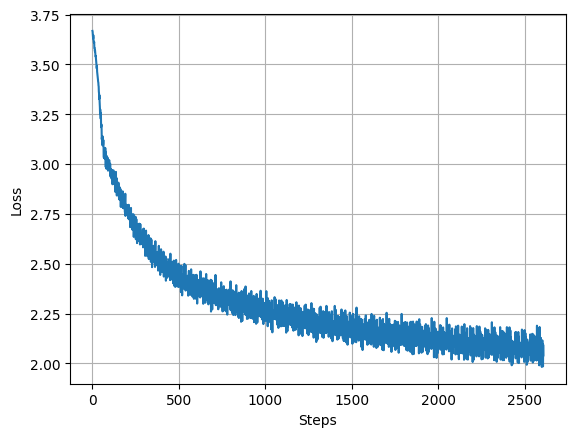

In [13]:
vocab_size = len(token_to_idx)
embedding_dim = 64
hidden_dim = 128
n_layers = 2

model_rnn = MyRNN(vocab_size, embedding_dim, hidden_dim, n_layers)

optimizer = optim.Adam(model_rnn.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

model_rnn = train_model(model_rnn, optimizer, criterion, encoded_text, 64, 18, 30)

Plot the loss function (axis X: number of epochs, axis Y: loss function).

In [14]:
def generate_sample(char_rnn, seed_phrase=' Hello', max_length=200, temperature=1.0):
    '''
    ### Disclaimer: this is an example function for text generation.
    ### You can either adapt it in your code or create your own function
    
    The function generates text given a phrase of length at least SEQ_LENGTH.
    :param seed_phrase: prefix characters. The RNN is asked to continue the phrase
    :param max_length: maximum output length, including seed_phrase
    :param temperature: coefficient for sampling.  higher temperature produces more chaotic outputs, 
        smaller temperature converges to the single most likely output.
        
    Be careful with the model output. This model waits logits (not probabilities/log-probabilities)
    of the next symbol.
    '''
    
    x_sequence = [token_to_idx[token] for token in seed_phrase]
    x_sequence = torch.tensor([x_sequence], dtype=torch.int64)
    hid_state = char_rnn.initial_state(batch_size=1)
    
    #feed the seed phrase, if any
    for i in range(len(seed_phrase) - 1):
        out, hid_state = char_rnn(x_sequence[:, i:i+1], hid_state)
    
    #start generating
    for _ in range(max_length - len(seed_phrase)):
        out, hid_state = char_rnn(x_sequence[:, -1:], hid_state)
        # Be really careful here with the model output
        p_next = F.softmax(out[:, -1, :] / temperature, dim=-1).data.numpy()[0]
        
        # sample next token and push it back into x_sequence
        next_ix = np.random.choice(len(idx_to_token), p=p_next)
        next_ix = torch.tensor([[next_ix]], dtype=torch.int64)
        x_sequence = torch.cat([x_sequence, next_ix], dim=1)
        
    return ''.join([idx_to_token[ix] for ix in x_sequence.data.numpy()[0]])

In [15]:
for temperature in [0.1, 0.2, 0.5, 1.0, 2.0]:
    print(generate_sample(model_rnn, "my glass shall not persuade me i am old", temperature=temperature))
    print("-----------------------------------------")

my glass shall not persuade me i am old the sore the to the shears the the the the the sell and sheed in the and the the so the erest the ender store the beath the thee the the in the the thou the so 
-----------------------------------------
my glass shall not persuade me i am old that the and the the thee the see mour on seath the the love the the the prom the thing the proud the of the mine the endes in the mare the and the the the the 
-----------------------------------------
my glass shall not persuade me i am old oun with daily deades thing llave, the stoud tine,
  whas the doud woend comt for shath my meath saist the thing in the breate all promg the beanty near ton the
-----------------------------------------
my glass shall not persuade me i am old bus chewe wor detit
  
 shy uso fich meob
  prowsiind;
  nots,
   sele,-aut bu louty ho:
  enattens iume no stave
  my love, cust to on in mower shame nethir mi
-----------------------------------------
my glass shall not persuade 

### More poetic model

Let's use LSTM instead of vanilla RNN and compare the results.

Plot the loss function of the number of epochs. Does the final loss become better?

In [17]:
class MyLSTM(nn.Module):
    
    def __init__(self, vocab_size, embedding_dim, hidden_dim, n_layers=1):
        super(MyLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, n_layers, batch_first=True, dropout=0.5)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x, hidden):
        x = self.embedding(x)
        out, hidden = self.lstm(x, hidden)
        out = self.dropout(out)
        out = self.fc(out)
        return out, hidden

    def initial_state(self, batch_size):
        return (
            torch.zeros(self.n_layers, batch_size, self.hidden_dim),
            torch.zeros(self.n_layers, batch_size, self.hidden_dim)
        )

Generate text using the trained net with different `temperature` parameter: `[0.1, 0.2, 0.5, 1.0, 2.0]`.

Evaluate the results visually, try to interpret them.

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [01:08<00:00,  2.29s/it]


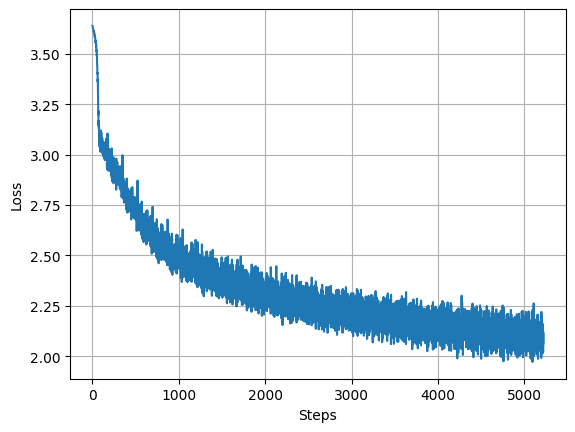

In [18]:
vocab_size = len(token_to_idx)
embedding_dim = 64
hidden_dim = 128
n_layers = 2

lstm_model = MyLSTM(vocab_size, embedding_dim, hidden_dim, n_layers)

optimizer = optim.Adam(lstm_model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

lstm_model = train_model(lstm_model, optimizer, criterion, encoded_text, 32, 18, 30)

In [19]:
for temperature in [0.1, 0.2, 0.5, 1.0, 2.0]:
    print(generate_sample(lstm_model, "my glass shall not persuade me i am old", temperature=temperature))
    print("-----------------------------------------")

my glass shall not persuade me i am old and to me thee,
  and the thine the theres the deest,
  and the sull the the the that the thee the that the so the shoe thee,
  thou more the the seare the the 
-----------------------------------------
my glass shall not persuade me i am old prove,
  not so the shee that the the thee the the me the seast the for the hing,
  whet the love where ther and and the the stell singer that the shousd and to
-----------------------------------------
my glass shall not persuade me i am old doth wils it o the sawel heer had i houf hould live, of prether wind,e in tise do that thee lavy beiend
  and sull youses than and the forr, theat my set sing o
-----------------------------------------
my glass shall not persuade me i am old the laile;
    belaty seed shy  colfflomk,sfere slile hasttyuin wee,
s  underenkem bore sees whlichrving o ffello; lumine
  enomise decerpove
s me plavy puy ter
-----------------------------------------
my glass shall not persuade 

### Saving and loading models

Save the model to the disk, then load it and generate text. Examples are available [here](https://pytorch.org/tutorials/beginner/saving_loading_models.html]).

In [20]:
sd = lstm_model.state_dict()
torch.save(sd,"lstm_model.pt")

In [21]:
sd = torch.load("lstm_model.pt", weights_only=True)
model = MyLSTM(vocab_size, embedding_dim, hidden_dim, n_layers)
model.load_state_dict(sd, strict=True)

<All keys matched successfully>

### References
1. <a href='http://karpathy.github.io/2015/05/21/rnn-effectiveness/'> Andrew Karpathy blog post about RNN. </a> 
There are several examples of genration: Shakespeare texts, Latex formulas, Linux Sourse Code and children names.
2. <a href='https://github.com/karpathy/char-rnn'> Repo with char-rnn code </a>
3. Cool repo with PyTorch examples: [link](https://github.com/spro/practical-pytorch`)